In [85]:
import seaborn as sns
import os
import pandas as pd
import numpy as np
np.random.seed(1337)
from IPython.display import Image
import matplotlib as mpl
import matplotlib.pyplot as plt
from pandas import read_csv
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

In [86]:
index_names = ['unit_nr', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['s_{}'.format(i) for i in range(1,22)] 
col_names = index_names + setting_names + sensor_names
test_df = pd.read_csv("/Users/seanhackenberg/School/Case Studies in ML/case-studies-ml-project-rul/data/test_FD001.txt",sep='\s+', header=None, names=col_names)
train_df = pd.read_csv("/Users/seanhackenberg/School/Case Studies in ML/case-studies-ml-project-rul/data/train_FD001.txt",sep='\s+', header=None, names=col_names)
RUL_df = pd.read_csv("/Users/seanhackenberg/School/Case Studies in ML/case-studies-ml-project-rul/data/RUL_FD001.txt",sep='\s+', header=None, names=['RUL'])

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/var/folders/ws/ry5x1yk962x496923v2x8q0c0000gn/T/ipykernel_97039/33335935.py:5: SyntaxWarning: invalid escape sequence '\s'
  test_df = pd.read_csv("/Users/seanhackenberg/School/Case Studies in ML/case-studies-ml-project-rul/data/test_FD001.txt",sep='\s+', header=None, names=col_names)
/var/folders/ws/ry5x1yk962x496923v2x8q0c0000gn/T/ipykernel_97039/33335935.py:6: SyntaxWarning: invalid escape sequence '\s'
  train_df = pd.read_csv("/Users/seanhackenberg/School/Case Studies in ML/case-studies-ml-project-rul/data/train_FD001.txt",sep='\s+', header=None, names=col_names)
/var/folders/ws/ry5x1yk962x496923v2x8q0c0000gn/T/ipykernel_97039/33335935.py:7: SyntaxWarning: invalid escape sequence '\s'


In [87]:
test_df.describe().T

,count,mean,std,min,25%,50%,75%,max
unit_nr,13096.0,51.543907,2.828942e+01,1.0000,28.0000,52.0000,76.0000,100.0000
time_cycles,13096.0,76.836515,5.305775e+01,1.0000,33.0000,69.0000,113.0000,303.0000
setting_1,13096.0,-0.000011,2.202685e-03,-0.0082,-0.0015,-0.0000,0.0015,0.0078
setting_2,13096.0,0.000004,2.940306e-04,-0.0006,-0.0002,-0.0000,0.0003,0.0007
setting_3,13096.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
s_1,13096.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
s_2,13096.0,642.475088,4.008993e-01,641.1300,642.1975,642.4600,642.7400,644.3000
s_3,13096.0,1588.099204,5.003274e+00,1569.0400,1584.6000,1587.9900,1591.3625,1607.5500
s_4,13096.0,1404.735362,6.688309e+00,1384.3900,1399.9500,1404.4400,1409.0500,1433.3600
s_5,13096.0,14.620000,1.776425e-15,14.6200,14.6200,14.6200,14.6200,14.6200


In [88]:
train_df.drop(['s_1', 's_5', 's_10', 's_16', 's_18', 's_19', 'setting_3'], axis=1, inplace=True, errors='ignore')
test_df.drop(['s_1', 's_5', 's_10', 's_16', 's_18', 's_19', 'setting_3'], axis=1, inplace=True, errors='ignore')

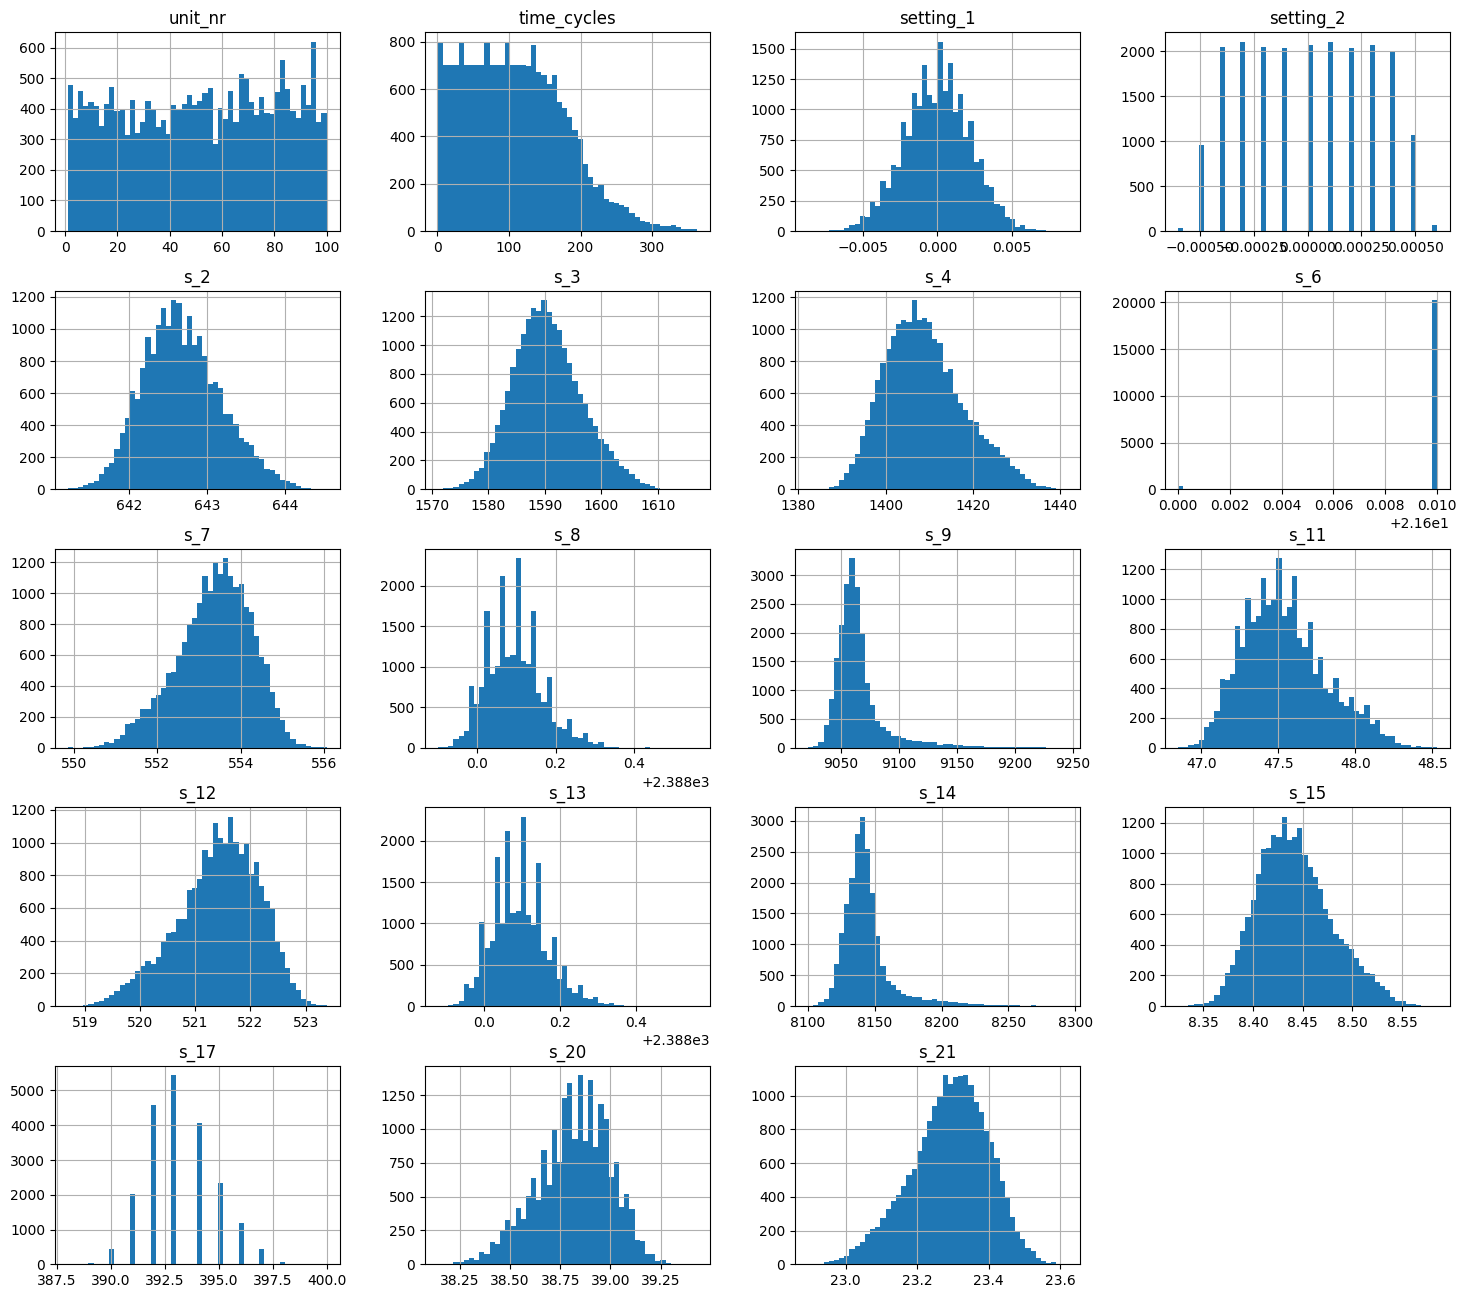

In [89]:
train_df.hist(bins=50, figsize=(18,16))
plt.show()

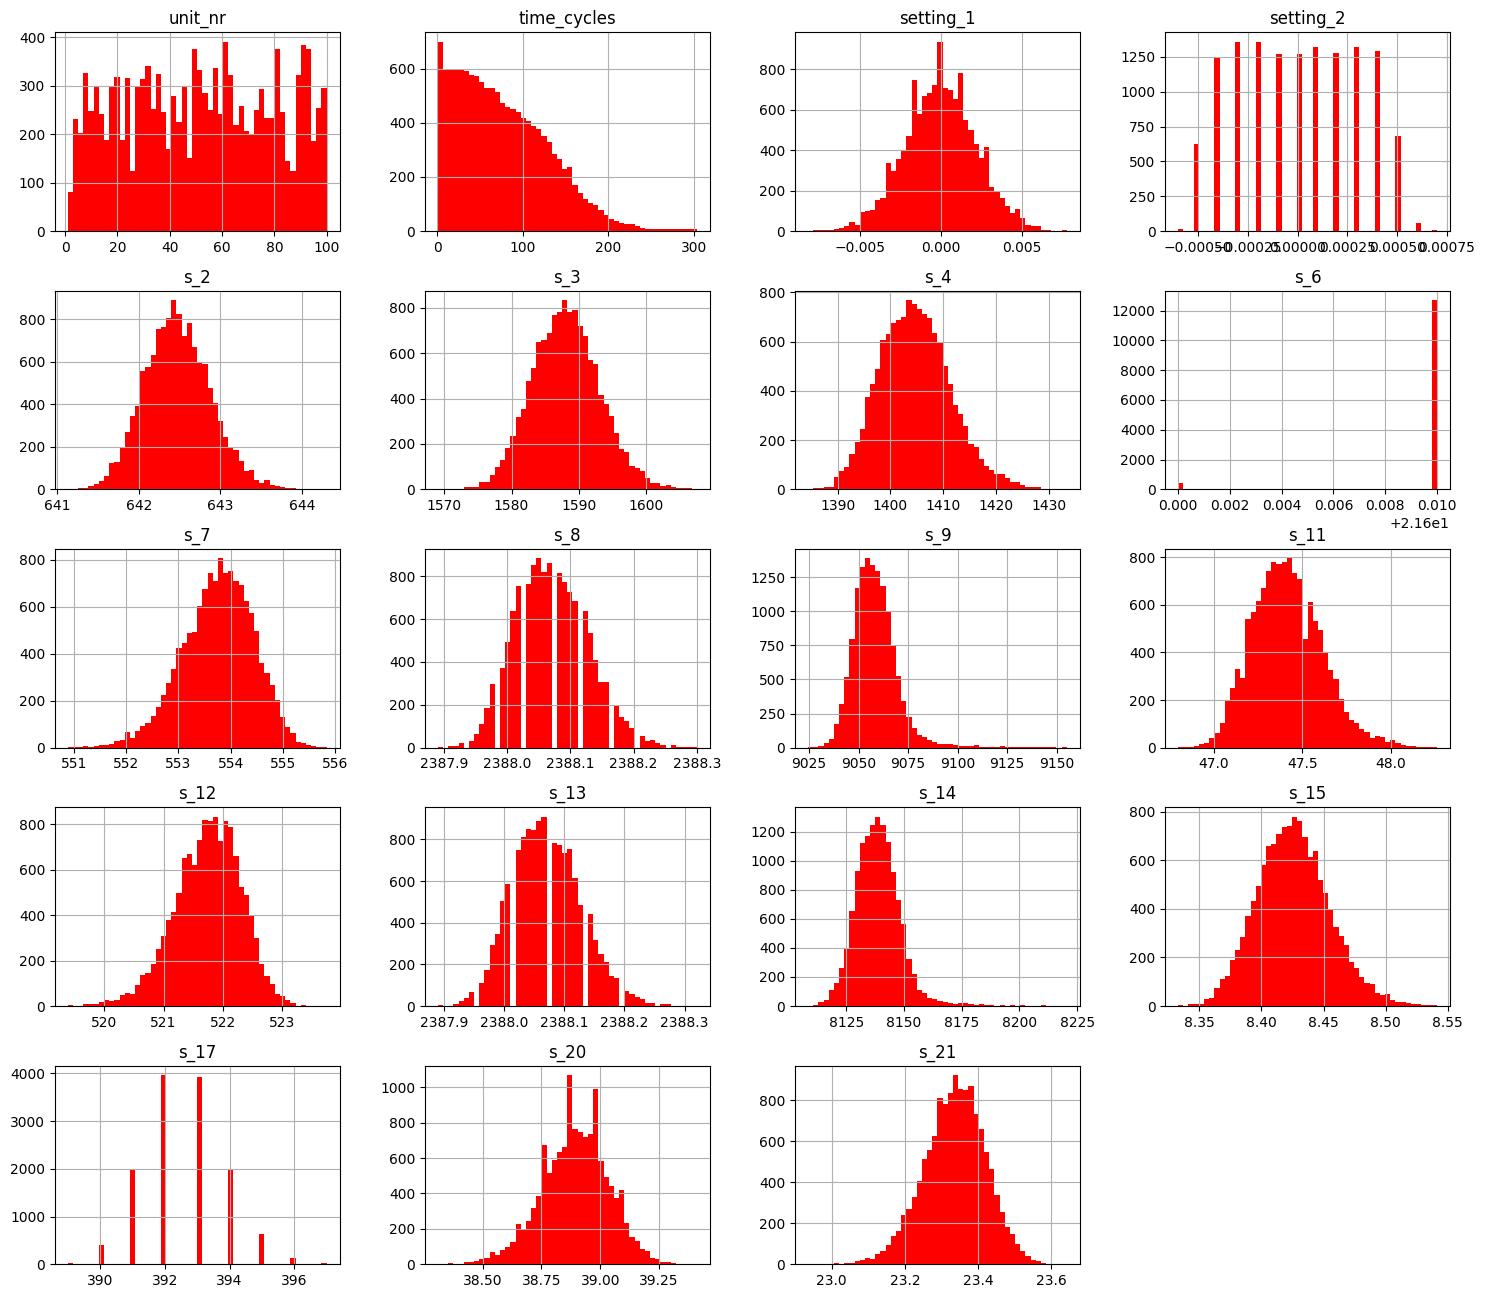

In [90]:
test_df.hist(bins=50, figsize=(18,16), color="red")
plt.show()

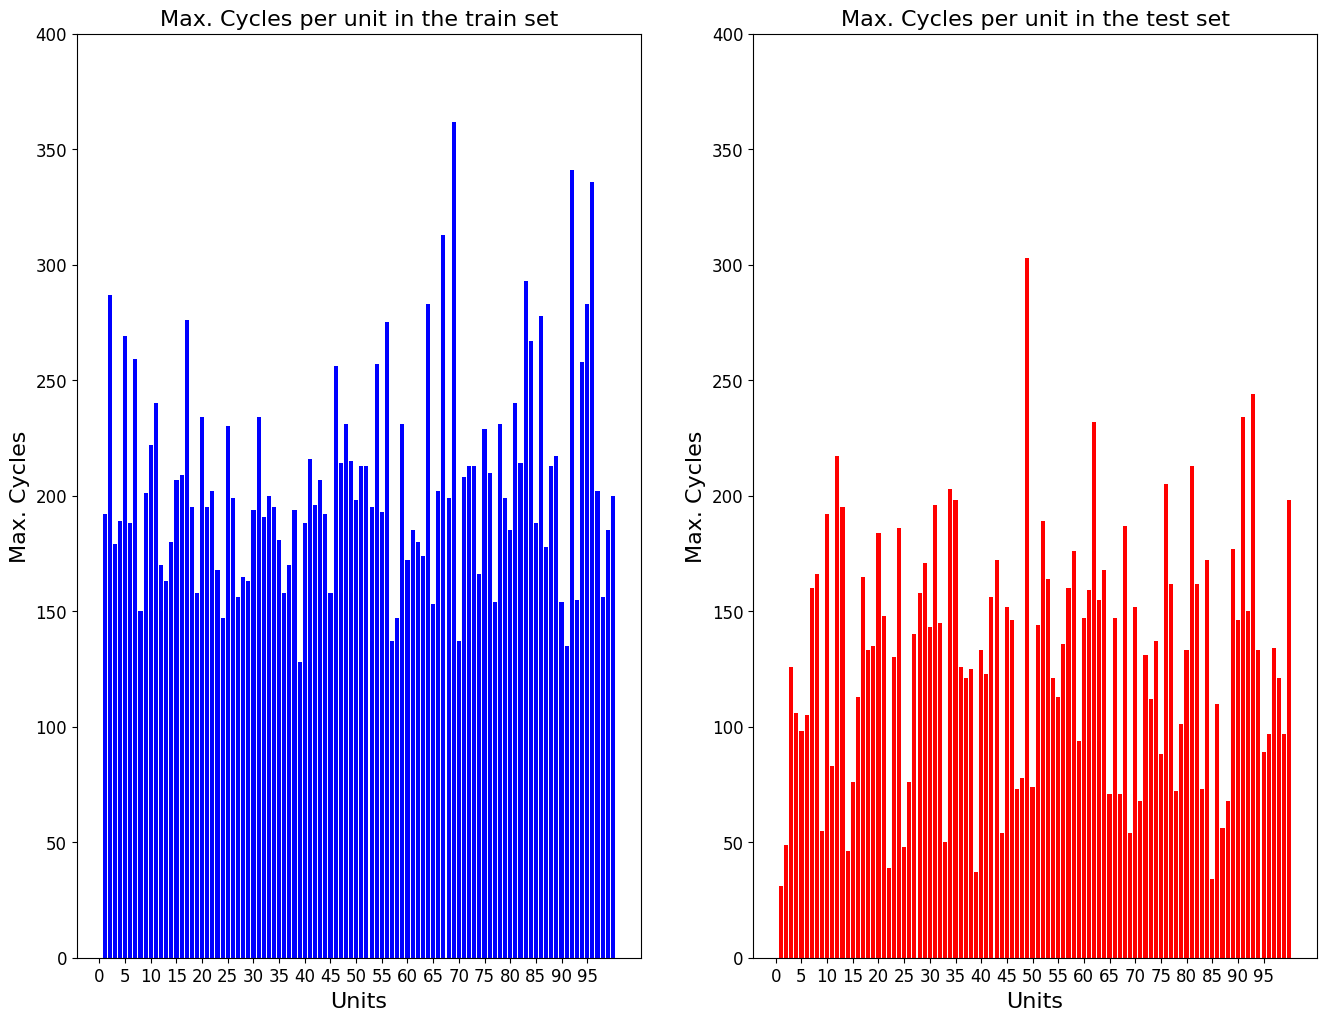

In [91]:
cyclestrain = train_df.groupby('unit_nr', as_index=False)['time_cycles'].max()
cyclestest = test_df.groupby('unit_nr', as_index=False)['time_cycles'].max()
fig = plt.figure(figsize = (16,12))
fig.add_subplot(1,2,1)
bar_labels = list(cyclestrain['unit_nr'])
bars = plt.bar(list(cyclestrain['unit_nr']), cyclestrain['time_cycles'], color='blue')
plt.ylim([0, 400])
plt.xlabel('Units', fontsize=16)
plt.ylabel('Max. Cycles', fontsize=16)
plt.title('Max. Cycles per unit in the train set', fontsize=16)
plt.xticks(np.arange(min(bar_labels)-1, max(bar_labels)-1, 5.0), fontsize=12)
plt.yticks(fontsize=12)
fig.add_subplot(1,2,2)
bars = plt.bar(list(cyclestest['unit_nr']), cyclestest['time_cycles'], color='red')
plt.ylim([0, 400])
plt.xlabel('Units', fontsize=16)
plt.ylabel('Max. Cycles', fontsize=16)
plt.title('Max. Cycles per unit in the test set', fontsize=16)
plt.xticks(np.arange(min(bar_labels)-1, max(bar_labels)-1, 5.0), fontsize=12)
plt.yticks(fontsize=12)
plt.show()

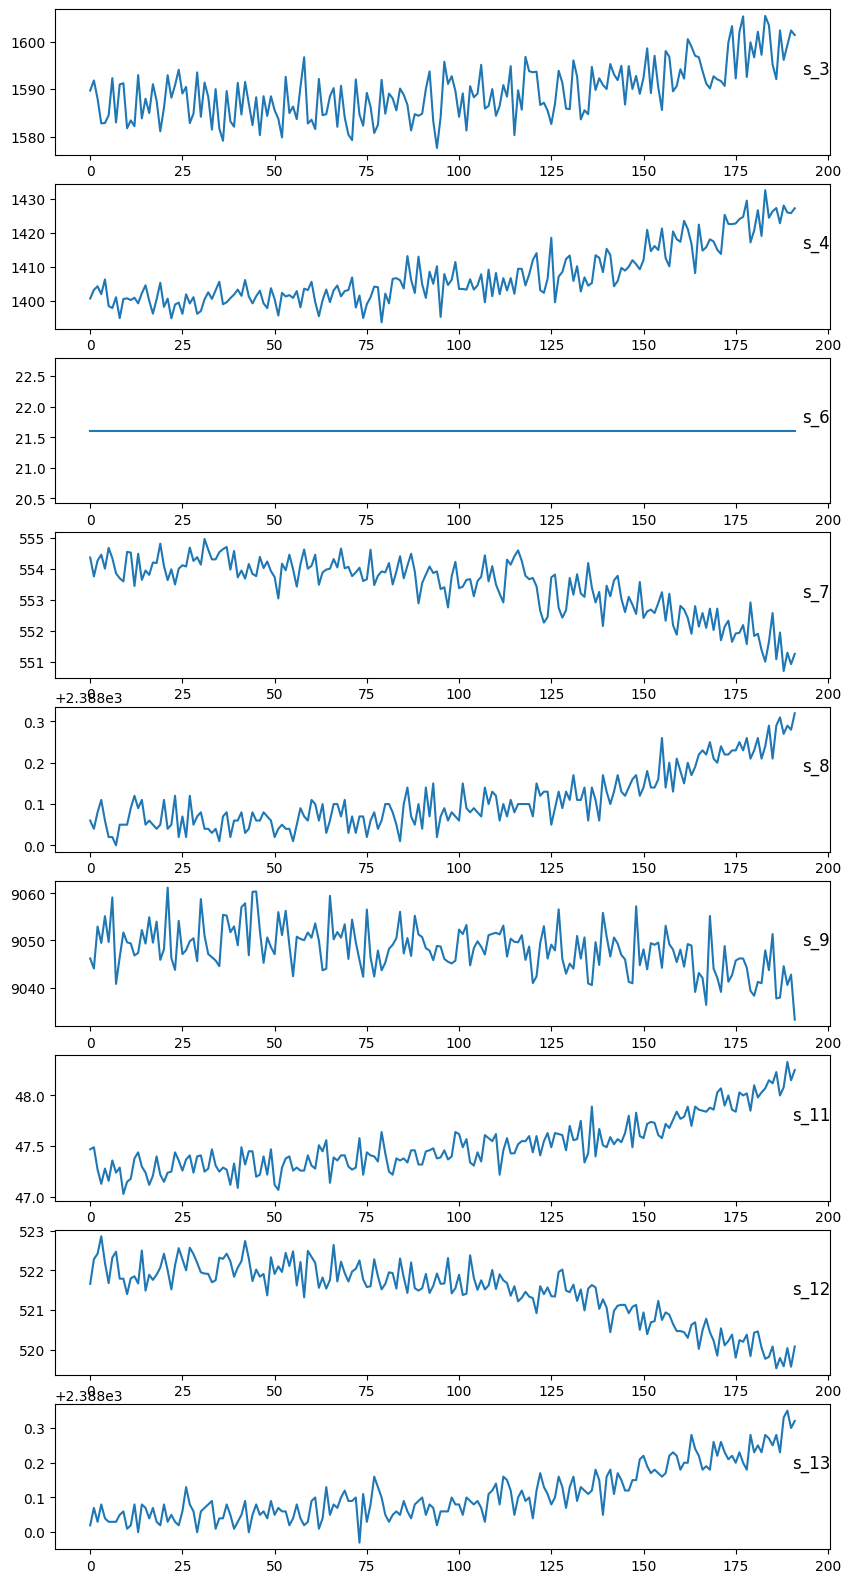

In [92]:
values = train_df[train_df["unit_nr"]==1].values
groups = [5, 6, 7, 8, 9, 10, 11,12,13]
i = 1
plt.figure(figsize=(10,20))
for group in groups:
 plt.subplot(len(groups), 1, i)
 plt.plot(values[:, group])
 plt.title(train_df.columns[group], y=0.5, loc='right')
 i += 1
plt.show()

In [93]:
train_df

,unit_nr,time_cycles,setting_1,setting_2,s_2,s_3,s_4,s_6,s_7,s_8,s_9,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,643.49,1597.98,1428.63,21.61,551.43,2388.19,9065.52,48.07,519.49,2388.26,8137.60,8.4956,397,38.49,22.9735
20627,100,197,-0.0016,-0.0005,643.54,1604.50,1433.58,21.61,550.86,2388.23,9065.11,48.04,519.68,2388.22,8136.50,8.5139,395,38.30,23.1594
20628,100,198,0.0004,0.0000,643.42,1602.46,1428.18,21.61,550.94,2388.24,9065.90,48.09,520.01,2388.24,8141.05,8.5646,398,38.44,22.9333
20629,100,199,-0.0011,0.0003,643.23,1605.26,1426.53,21.61,550.68,2388.25,9073.72,48.39,519.67,2388.23,8139.29,8.5389,395,38.29,23.0640


## Feature Engineering

In [94]:
# Getting Max Cycles for each engine unit
train_df = pd.merge(train_df, train_df.groupby('unit_nr', as_index=False)['time_cycles'].max(),how='left', on='unit_nr')
train_df.rename(columns={"time_cycles_x": "time_cycles", "time_cycles_y": "max_cycles"}, inplace=True)
test_df = pd.merge(test_df, test_df.groupby('unit_nr', as_index=False)['time_cycles'].max(),how='left', on='unit_nr')
test_df.rename(columns={"time_cycles_x": "time_cycles", "time_cycles_y": "max_cycles"}, inplace=True)

# Adding Time to Failure (TTF)
train_df["TTF"] = train_df["max_cycles"] - train_df["time_cycles"]
test_df["TTF"] = test_df["max_cycles"] - test_df["time_cycles"]

# Cap TTF at 150 cycles
# train_df["TTF"] = np.minimum(train_df["TTF"], 150)
# test_df["TTF"] = np.minimum(test_df["TTF"], 150)

# Scaling features
MinMaxScaler = MinMaxScaler()
scaled_train_df = train_df.copy()
scaled_train_df.iloc[:,2:19] = MinMaxScaler.fit_transform(scaled_train_df.iloc[:,2:19])

scaled_test_df = test_df.copy()
scaled_test_df.iloc[:,2:19] = MinMaxScaler.transform(scaled_test_df.iloc[:,2:19])

# Add fractional TTF
scaled_train_df['FTTF'] = scaled_train_df["TTF"] / scaled_train_df["max_cycles"]
scaled_test_df['FTTF'] = scaled_test_df["TTF"] / scaled_test_df["max_cycles"]

# Cap fractional TTF at 1.0
# scaled_train_df['FTTF'] = np.minimum(scaled_train_df['FTTF'], 1.0)
# scaled_test_df['FTTF'] = np.minimum(scaled_test_df['FTTF'], 1.0)

/var/folders/ws/ry5x1yk962x496923v2x8q0c0000gn/T/ipykernel_97039/331586868.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.33333333 0.33333333 0.16666667 ... 0.83333333 0.58333333 0.66666667]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  scaled_train_df.iloc[:,2:19] = MinMaxScaler.fit_transform(scaled_train_df.iloc[:,2:19])
/var/folders/ws/ry5x1yk962x496923v2x8q0c0000gn/T/ipykernel_97039/331586868.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.33333333 0.41666667 0.41666667 ... 0.58333333 0.58333333 0.66666667]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  scaled_test_df.iloc[:,2:19] = MinMaxScaler.transform(scaled_test_df.iloc[:,2:19])


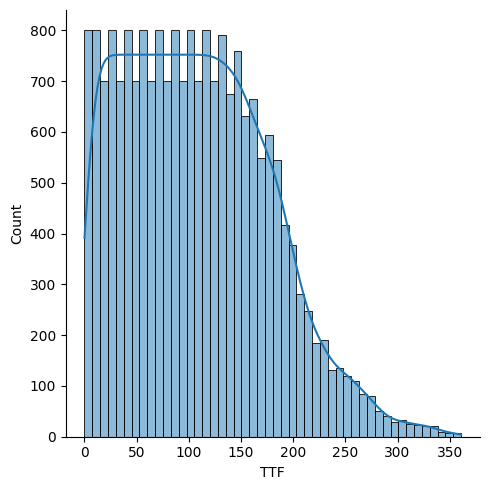

In [95]:
sns.displot(train_df["TTF"], kde=True)

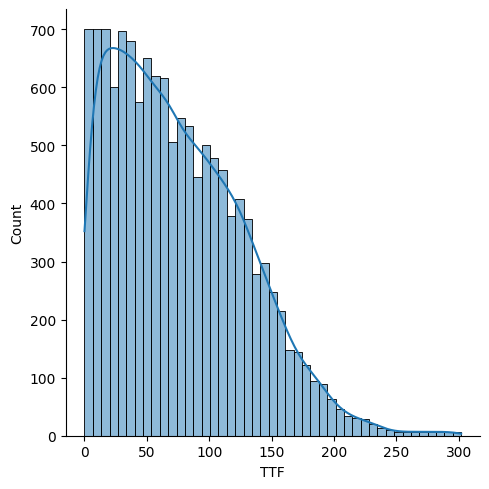

In [96]:
sns.displot(test_df["TTF"], kde=True)

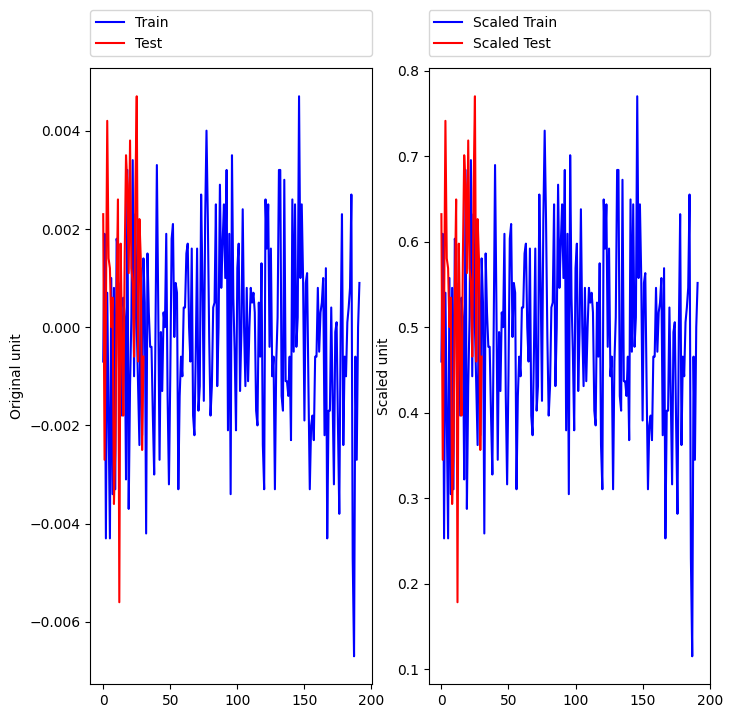

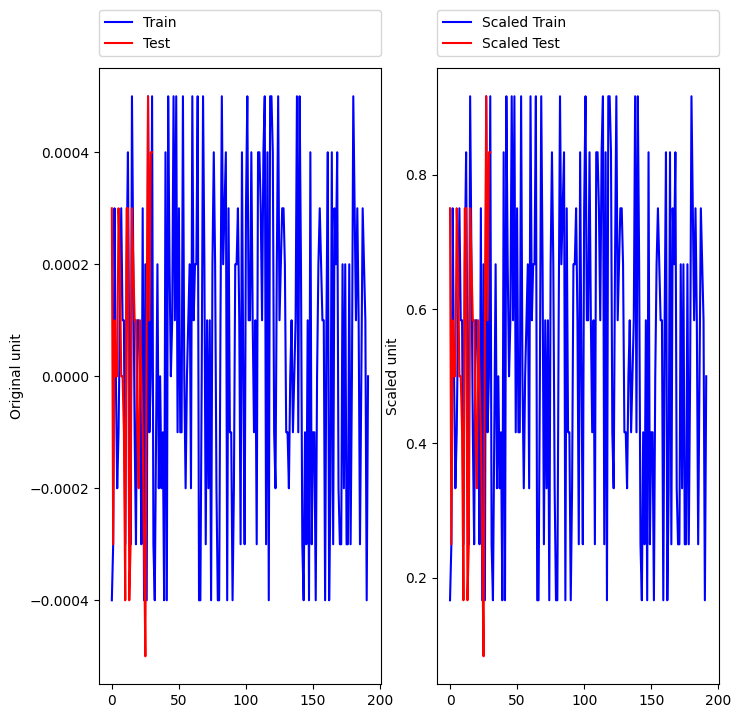

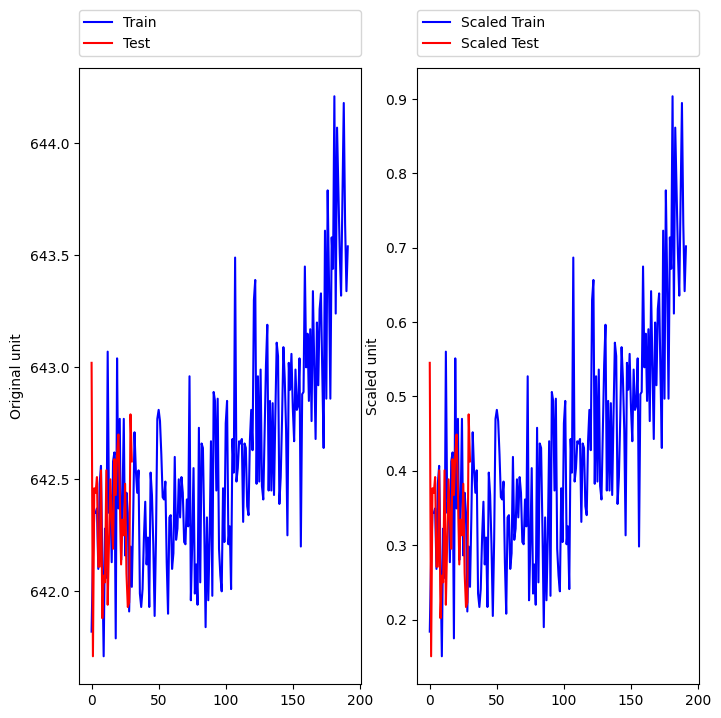

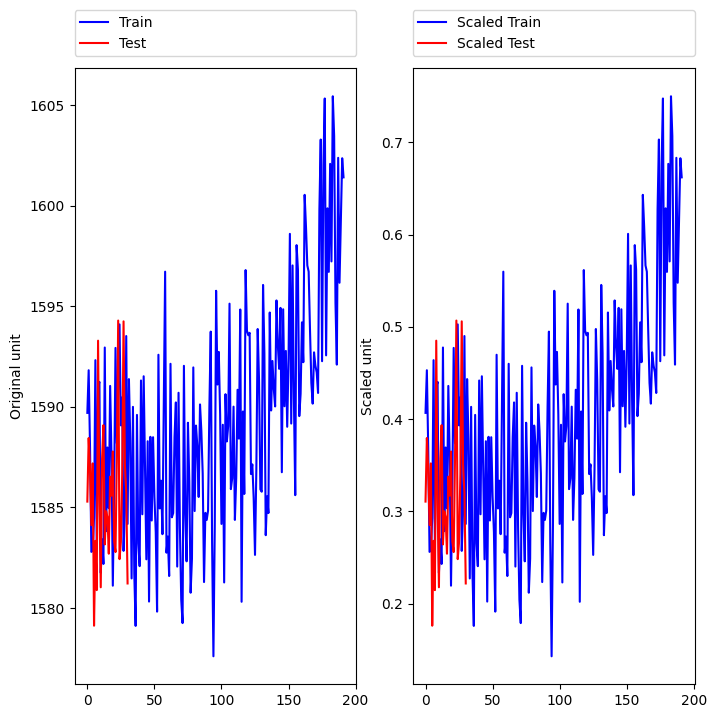

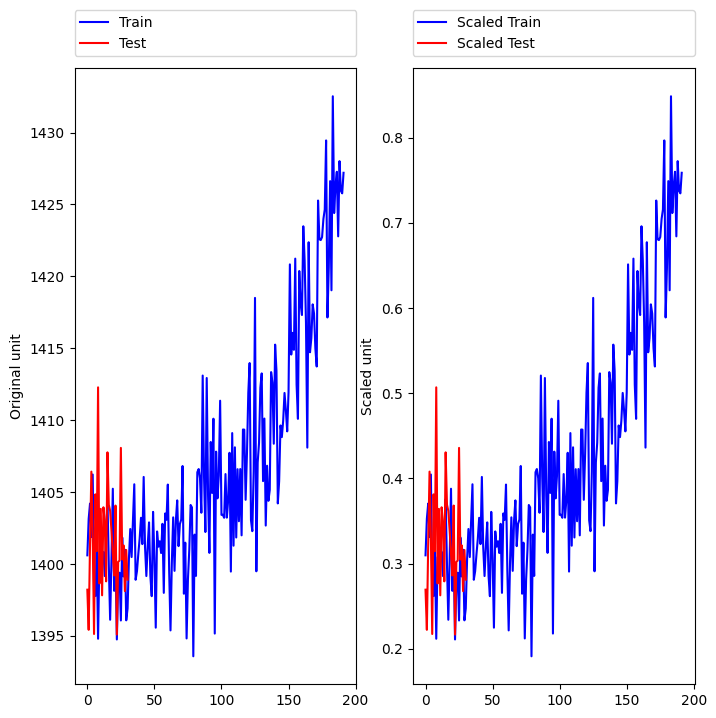

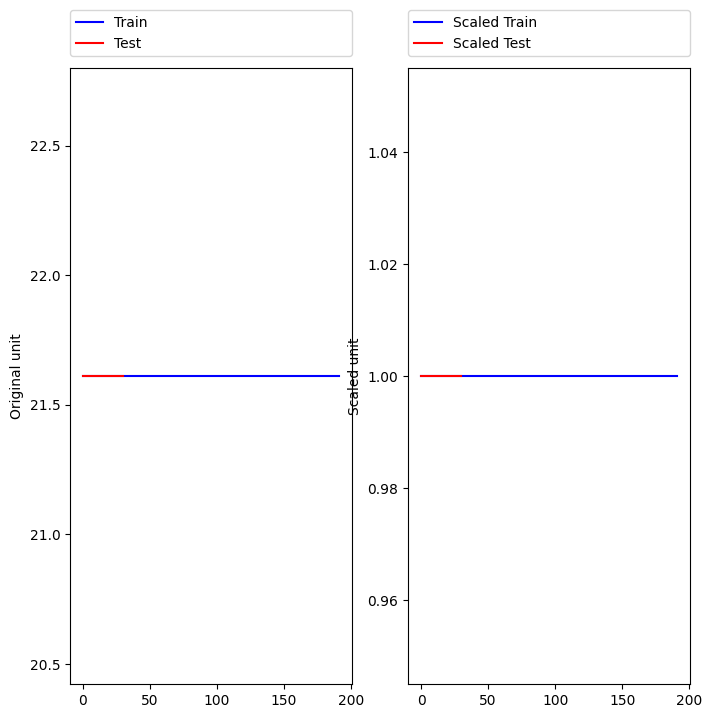

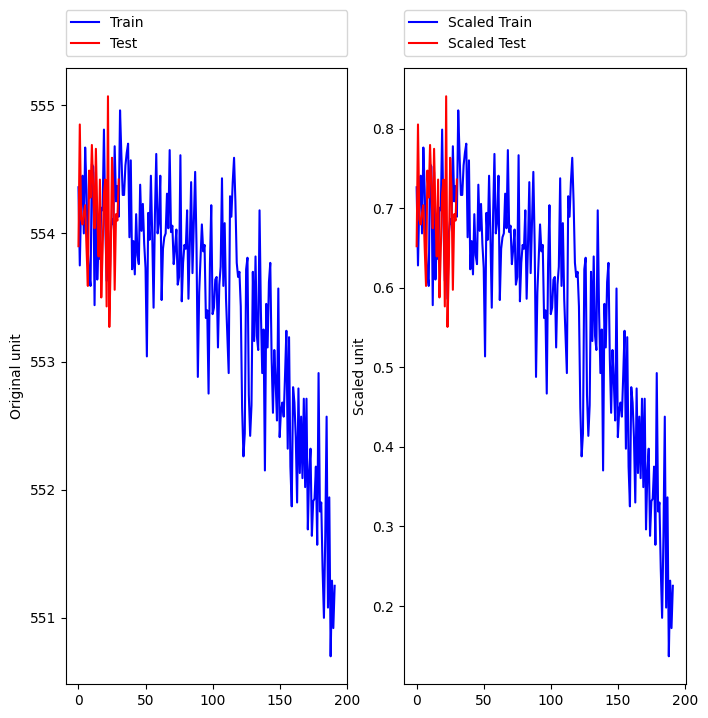

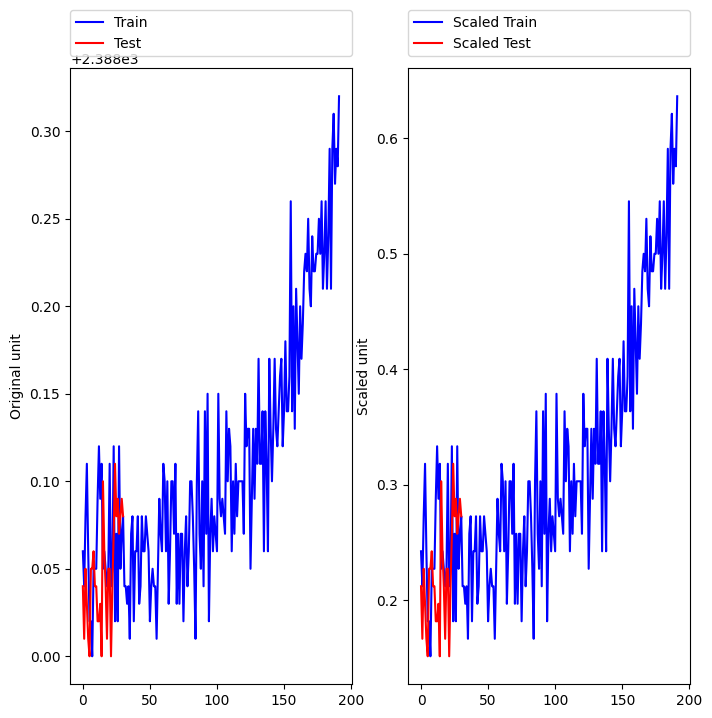

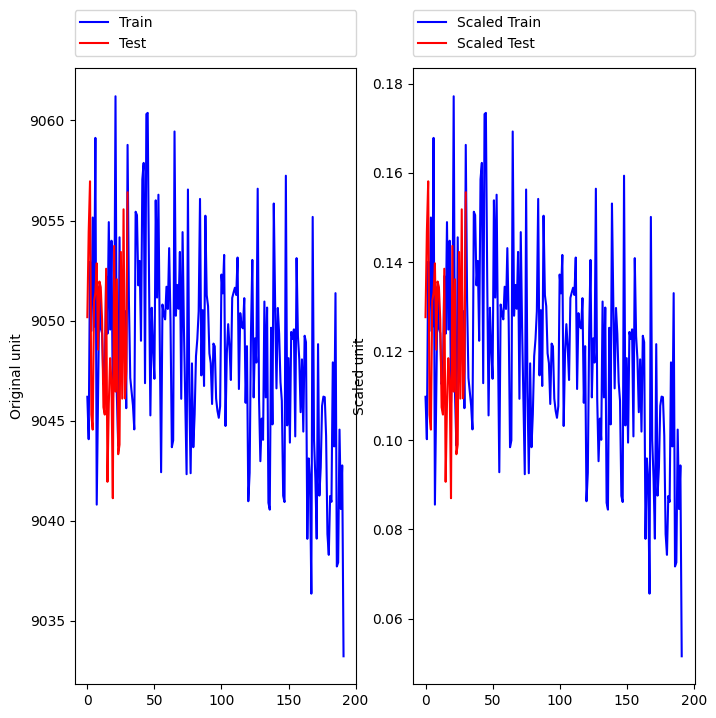

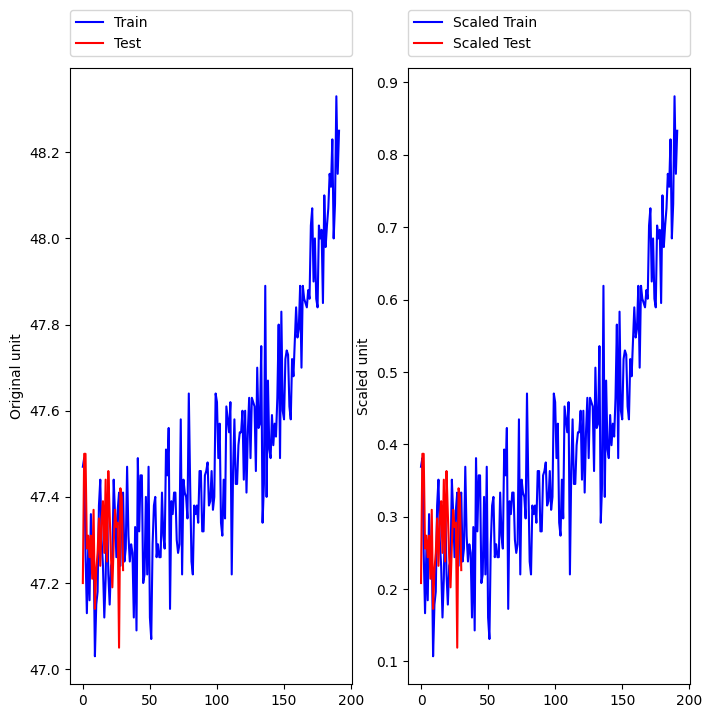

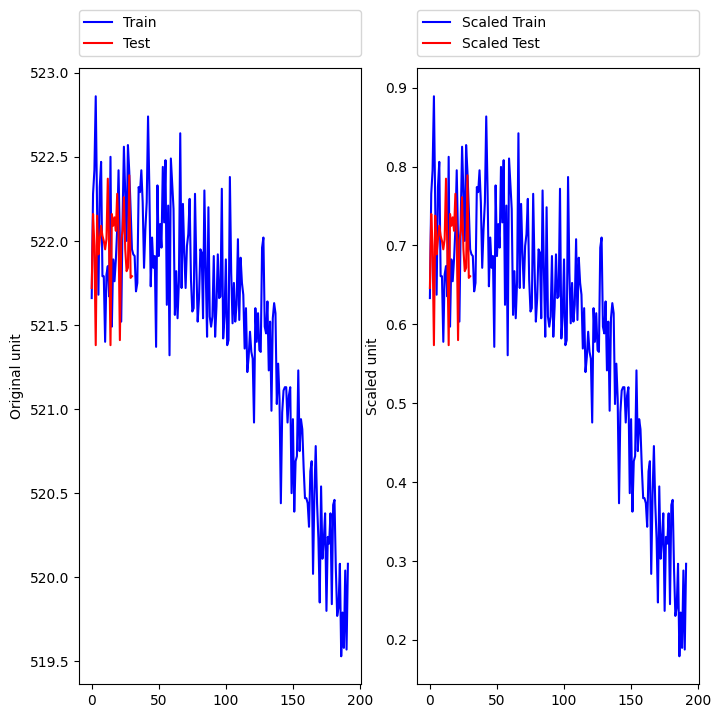

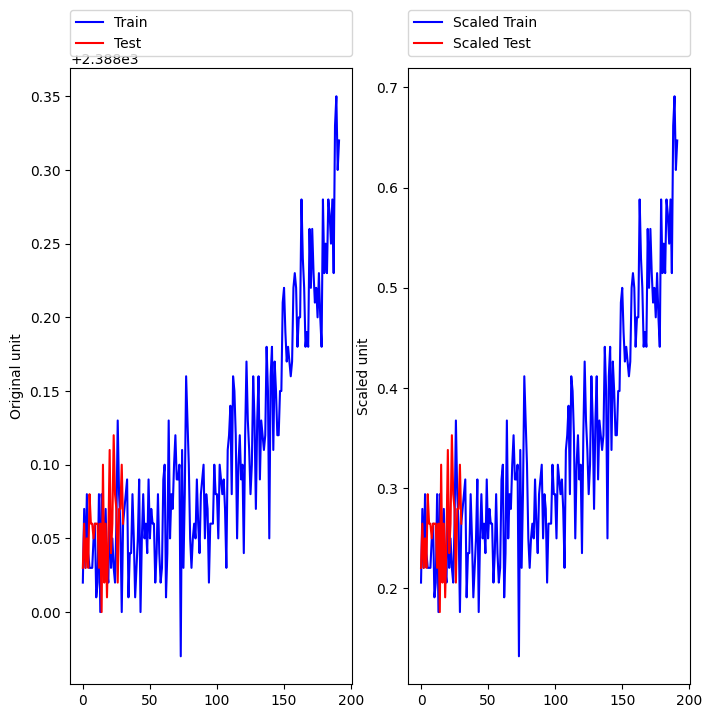

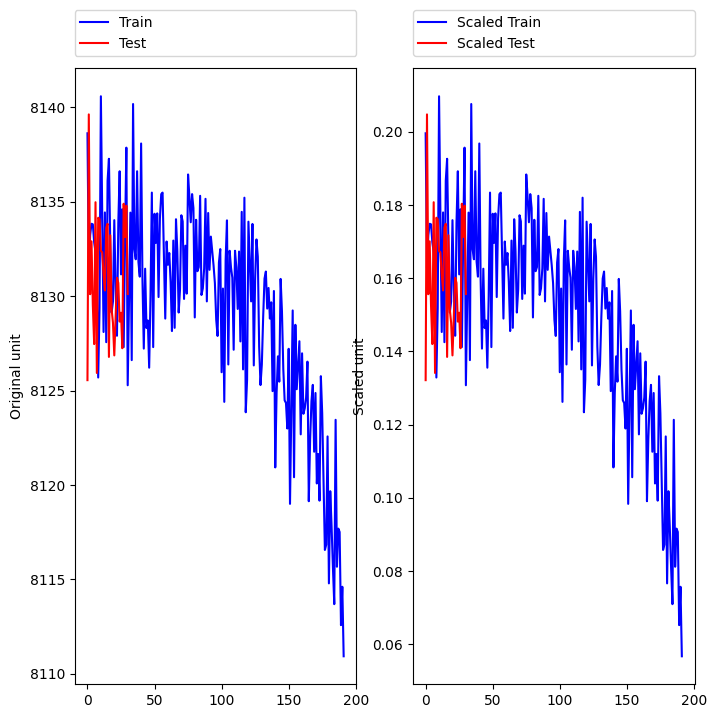

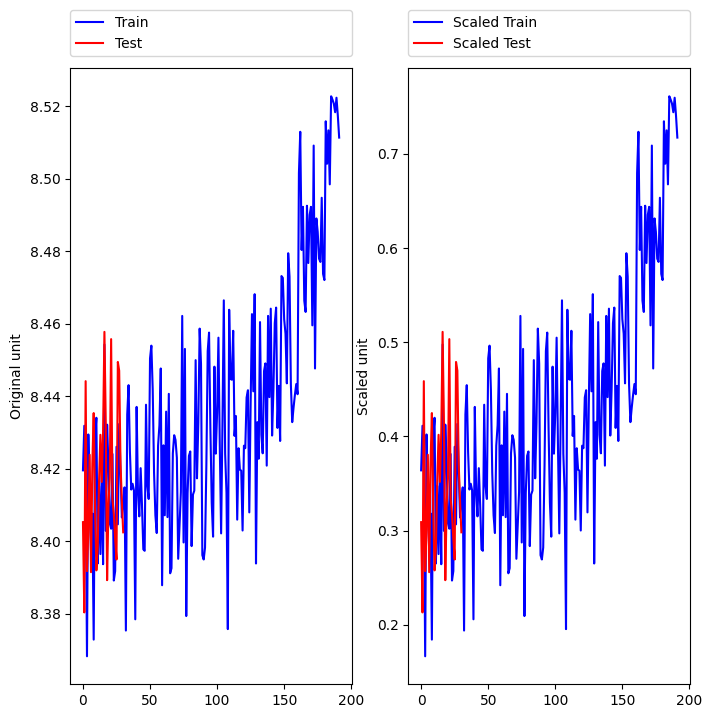

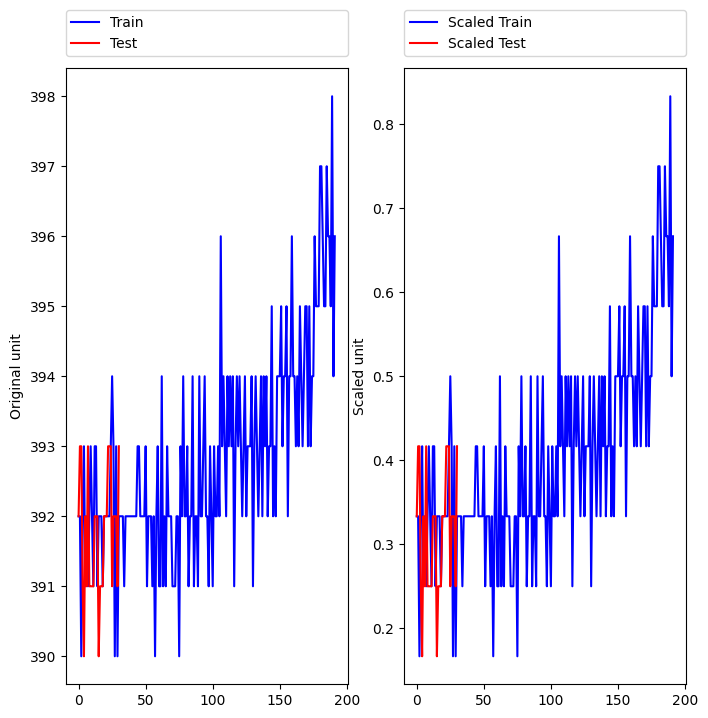

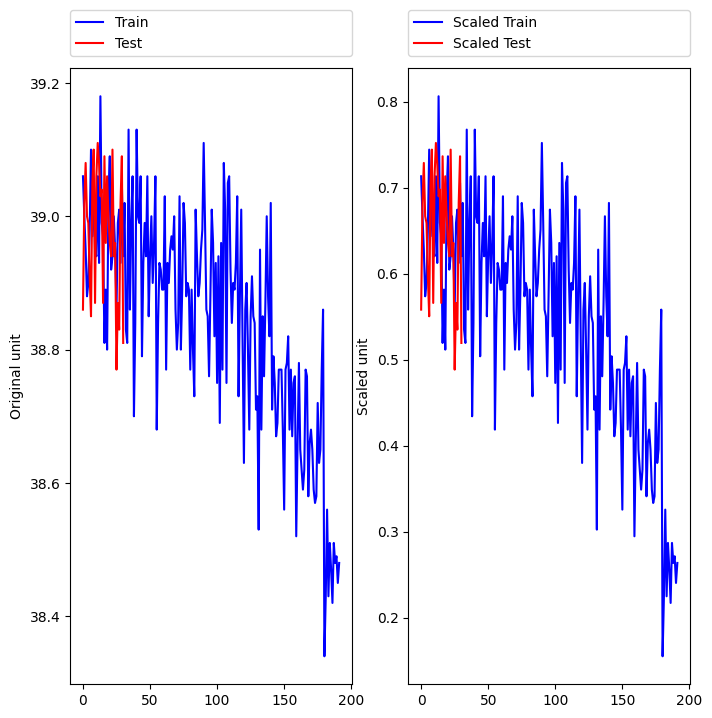

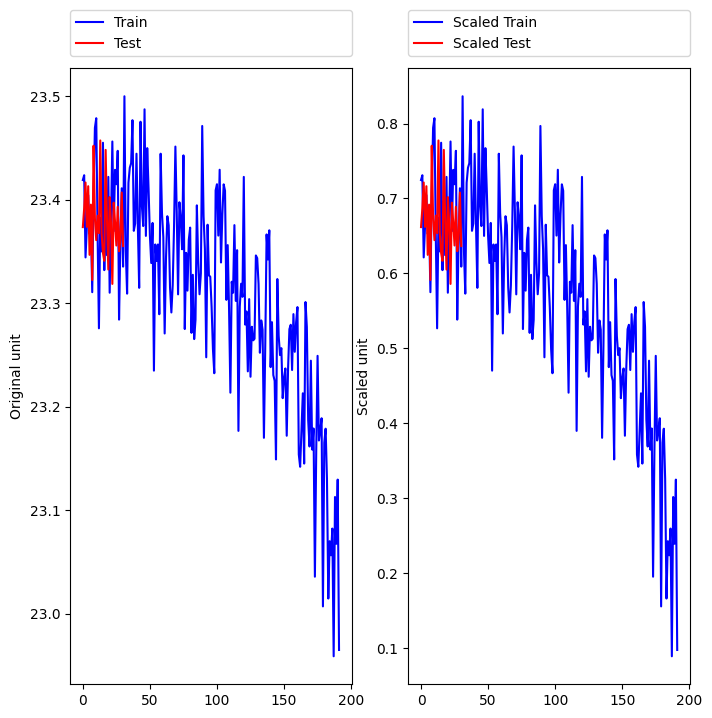

In [97]:
for col in train_df.columns[2:19]:
    fig = plt.figure(figsize = (8, 8))
    fig.add_subplot(1,2,1)
    plt.plot(train_df[train_df.unit_nr==1][col], color="blue")
    plt.plot(test_df[test_df.unit_nr==1][col], color="red")
    plt.legend(['Train','Test'], bbox_to_anchor=(0., 1.02, 1., .102), loc=3, mode="expand", borderaxespad=0)
    plt.ylabel('Original unit')
    fig.add_subplot(1,2,2)
    plt.plot(scaled_train_df[scaled_train_df.unit_nr==1][col], color="blue")
    plt.plot(scaled_test_df[scaled_test_df.unit_nr==1][col], color="red")
    plt.legend(['Scaled Train','Scaled Test'], bbox_to_anchor=(0., 1.02, 1., .102), loc=3, mode="expand", borderaxespad=0)
    plt.ylabel('Scaled unit')
    plt.show()

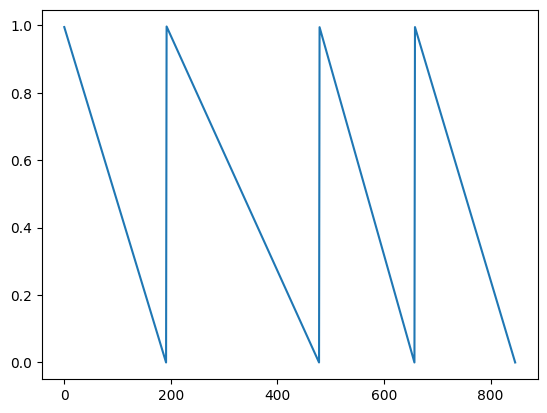

In [98]:
plt.plot(scaled_train_df[scaled_train_df["unit_nr"] < 5]["FTTF"])
plt.show()


In [99]:
X_train = scaled_train_df.iloc[:,1:19]
Y_train = scaled_train_df["FTTF"]   

X_test = scaled_test_df.iloc[:,1:19]
Y_test = scaled_test_df["FTTF"]

## Model Building - Modular Approach

In [100]:
# Import additional models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

def transform_predictions_to_ttf(y_pred_fttf, y_test_fttf, test_df):
    """Transform fractional TTF predictions back to TTF scale"""
    test_max_cycles = test_df.groupby('unit_nr')['max_cycles'].first()
    
    Y_predict_TTF = []
    Y_test_TTF = []
    
    for unit_nr in test_df['unit_nr'].unique():
        unit_mask = test_df['unit_nr'] == unit_nr
        max_cycles = test_max_cycles[unit_nr]
        
        # Get predictions and actual values for this unit
        unit_predictions = y_pred_fttf[unit_mask]
        unit_actual = y_test_fttf[unit_mask]
        
        # Transform back to TTF scale
        Y_predict_TTF.extend(unit_predictions * max_cycles)
        Y_test_TTF.extend(unit_actual * max_cycles)
    
    return np.array(Y_predict_TTF), np.array(Y_test_TTF)

def evaluate_model(model, X_train, Y_train, X_test, Y_test, model_name, test_df):
    """Train model and return comprehensive evaluation metrics"""
    print(f"\n{'='*50}")
    print(f"Training {model_name}")
    print(f"{'='*50}")
    
    # Training
    start_time = time.time()
    model.fit(X_train, Y_train)
    training_time = time.time() - start_time
    
    # Predictions
    start_time = time.time()
    Y_pred_train = model.predict(X_train)
    Y_pred_test = model.predict(X_test)
    inference_time = time.time() - start_time
    
    # FTTF scale metrics
    train_rmse_fttf = np.sqrt(mean_squared_error(Y_train, Y_pred_train))
    test_rmse_fttf = np.sqrt(mean_squared_error(Y_test, Y_pred_test))
    test_mae_fttf = mean_absolute_error(Y_test, Y_pred_test)
    test_r2_fttf = r2_score(Y_test, Y_pred_test)
    
    # TTF scale metrics
    Y_pred_test_ttf, Y_test_ttf = transform_predictions_to_ttf(Y_pred_test, Y_test, test_df)
    test_rmse_ttf = np.sqrt(mean_squared_error(Y_test_ttf, Y_pred_test_ttf))
    test_mae_ttf = mean_absolute_error(Y_test_ttf, Y_pred_test_ttf)
    
    # Print results
    print(f"Training Time: {training_time:.3f} seconds")
    print(f"Inference Time: {inference_time:.3f} seconds")
    print(f"\nFTTF Scale Metrics:")
    print(f"  Train RMSE: {train_rmse_fttf:.6f}")
    print(f"  Test RMSE:  {test_rmse_fttf:.6f}")
    print(f"  Test MAE:   {test_mae_fttf:.6f}")
    print(f"  Test R²:    {test_r2_fttf:.6f}")
    print(f"\nTTF Scale Metrics:")
    print(f"  Test RMSE:  {test_rmse_ttf:.2f} cycles")
    print(f"  Test MAE:   {test_mae_ttf:.2f} cycles")
    print(f"  Mean Actual TTF: {Y_test_ttf.mean():.2f} cycles")
    print(f"  Mean Predicted TTF: {Y_pred_test_ttf.mean():.2f} cycles")
    
    return {
        'model': model,
        'model_name': model_name,
        'training_time': training_time,
        'inference_time': inference_time,
        'train_rmse_fttf': train_rmse_fttf,
        'test_rmse_fttf': test_rmse_fttf,
        'test_mae_fttf': test_mae_fttf,
        'test_r2_fttf': test_r2_fttf,
        'test_rmse_ttf': test_rmse_ttf,
        'test_mae_ttf': test_mae_ttf,
        'Y_pred_test': Y_pred_test,
        'Y_pred_test_ttf': Y_pred_test_ttf,
        'Y_test_ttf': Y_test_ttf
    }

In [101]:
# Define models to test
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'SVR': SVR(kernel='rbf', C=1.0, gamma='scale'),
    'Neural Network': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
}

# Store results
results = {}

# Evaluate each model
for model_name, model in models.items():
    results[model_name] = evaluate_model(
        model, X_train, Y_train, X_test, Y_test, model_name, scaled_test_df
    )


Training Random Forest
Training Time: 11.513 seconds
Inference Time: 0.392 seconds

FTTF Scale Metrics:
  Train RMSE: 0.022529
  Test RMSE:  0.205913
  Test MAE:   0.149625
  Test R²:    0.491186

TTF Scale Metrics:
  Test RMSE:  23.57 cycles
  Test MAE:   18.76 cycles
  Mean Actual TTF: 75.84 cycles
  Mean Predicted TTF: 93.01 cycles

Training Gradient Boosting
Training Time: 3.501 seconds
Inference Time: 0.015 seconds

FTTF Scale Metrics:
  Train RMSE: 0.058953
  Test RMSE:  0.207060
  Test MAE:   0.151214
  Test R²:    0.485498

TTF Scale Metrics:
  Test RMSE:  23.84 cycles
  Test MAE:   19.03 cycles
  Mean Actual TTF: 75.84 cycles
  Mean Predicted TTF: 93.21 cycles

Training Linear Regression
Training Time: 0.003 seconds
Inference Time: 0.001 seconds

FTTF Scale Metrics:
  Train RMSE: 0.102694
  Test RMSE:  0.221841
  Test MAE:   0.169769
  Test R²:    0.409421

TTF Scale Metrics:
  Test RMSE:  27.35 cycles
  Test MAE:   22.47 cycles
  Mean Actual TTF: 75.84 cycles
  Mean Predicte


MODEL COMPARISON SUMMARY
               Model  Train RMSE (FTTF)  Test RMSE (FTTF)  Test RMSE (TTF)  \
5                SVR             0.0788            0.1961          21.7806   
0      Random Forest             0.0225            0.2059          23.5705   
1  Gradient Boosting             0.0590            0.2071          23.8384   
4   Lasso Regression             0.1215            0.2065          24.9828   
3   Ridge Regression             0.1027            0.2218          27.3487   
2  Linear Regression             0.1027            0.2218          27.3519   
6     Neural Network             0.0999            0.2545          32.3778   

   Test MAE (TTF)  Test R²  Training Time (s)  Inference Time (s)  
5         17.6196   0.5385             1.0067              2.8411  
0         18.7589   0.4912            11.5129              0.3915  
1         19.0300   0.4855             3.5007              0.0147  
4         19.9391   0.4884             0.0008              0.0005  
3        

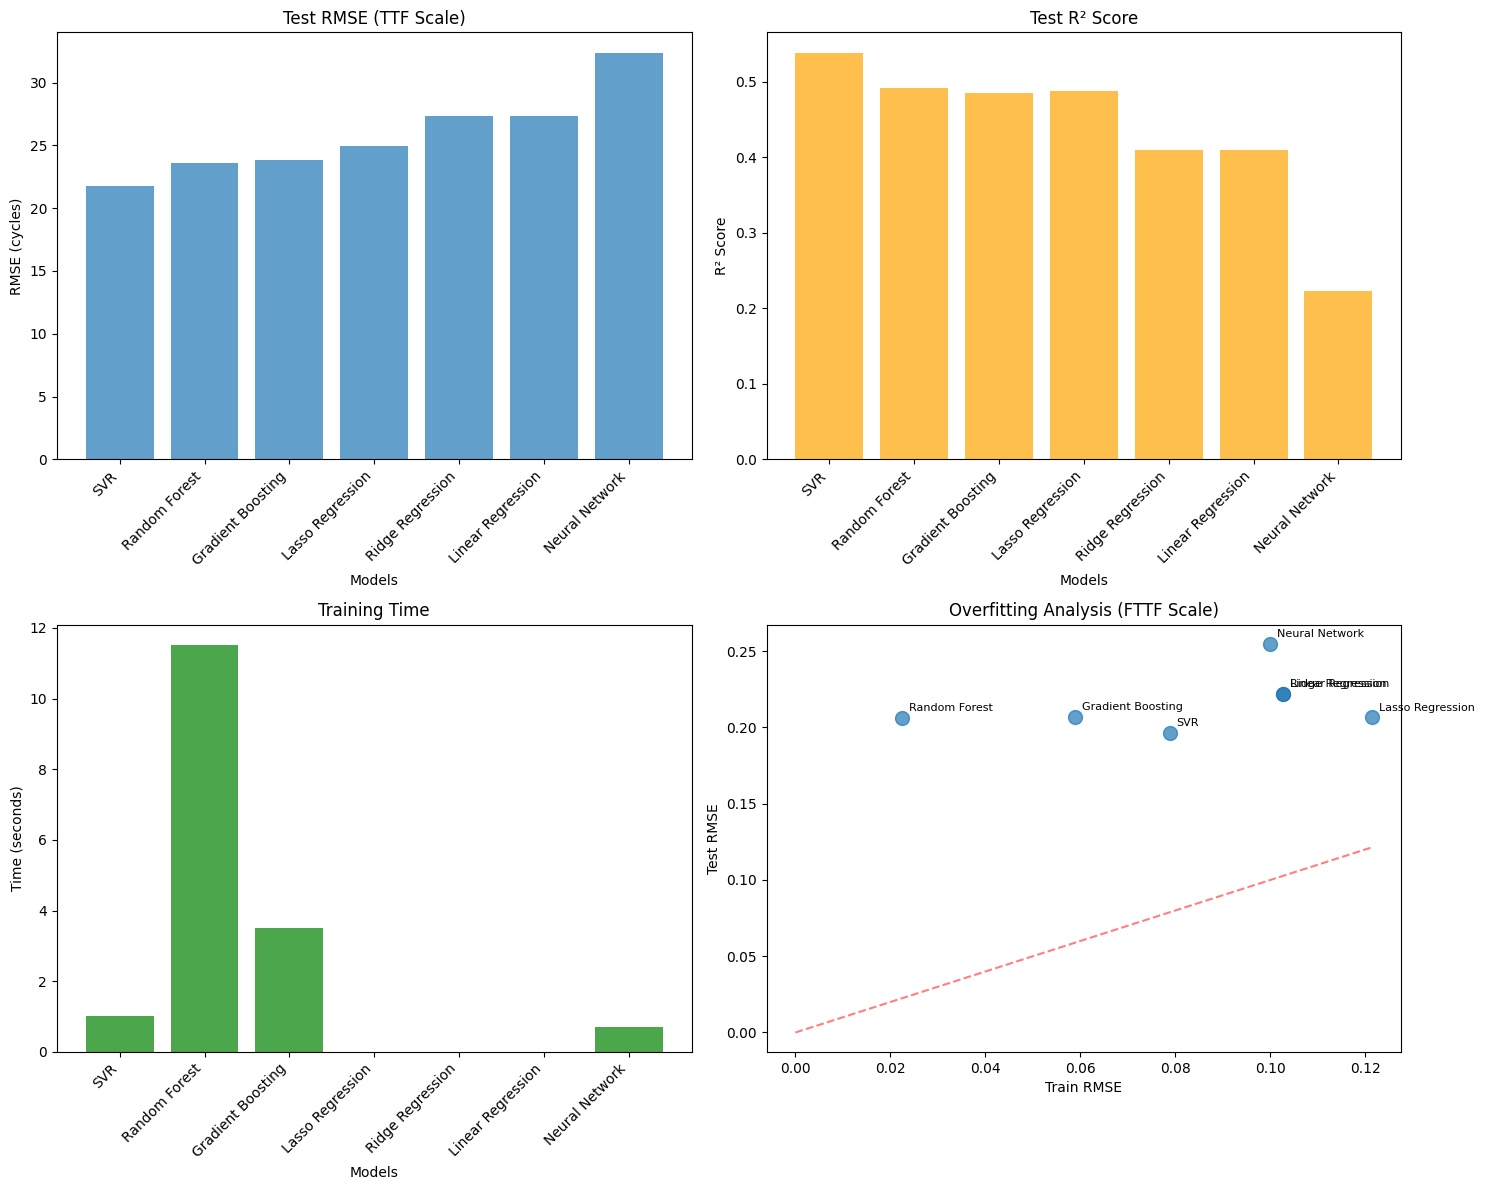


Best performing model: SVR
Test RMSE (TTF): 21.78 cycles


In [102]:
# Create results summary
print(f"\n{'='*80}")
print("MODEL COMPARISON SUMMARY")
print(f"{'='*80}")

results_df = pd.DataFrame([
    {
        'Model': result['model_name'],
        'Train RMSE (FTTF)': result['train_rmse_fttf'],
        'Test RMSE (FTTF)': result['test_rmse_fttf'],
        'Test RMSE (TTF)': result['test_rmse_ttf'],
        'Test MAE (TTF)': result['test_mae_ttf'],
        'Test R²': result['test_r2_fttf'],
        'Training Time (s)': result['training_time'],
        'Inference Time (s)': result['inference_time']
    }
    for result in results.values()
])

# Sort by test RMSE (TTF)
results_df = results_df.sort_values('Test RMSE (TTF)')
print(results_df.round(4))

# Visualize model performance
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# RMSE comparison
ax1 = axes[0, 0]
x_pos = np.arange(len(results_df))
ax1.bar(x_pos, results_df['Test RMSE (TTF)'], alpha=0.7)
ax1.set_title('Test RMSE (TTF Scale)')
ax1.set_xlabel('Models')
ax1.set_ylabel('RMSE (cycles)')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(results_df['Model'], rotation=45, ha='right')

# R² comparison
ax2 = axes[0, 1]
ax2.bar(x_pos, results_df['Test R²'], alpha=0.7, color='orange')
ax2.set_title('Test R² Score')
ax2.set_xlabel('Models')
ax2.set_ylabel('R² Score')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(results_df['Model'], rotation=45, ha='right')

# Training time comparison
ax3 = axes[1, 0]
ax3.bar(x_pos, results_df['Training Time (s)'], alpha=0.7, color='green')
ax3.set_title('Training Time')
ax3.set_xlabel('Models')
ax3.set_ylabel('Time (seconds)')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(results_df['Model'], rotation=45, ha='right')

# Overfitting analysis (Train vs Test RMSE)
ax4 = axes[1, 1]
ax4.scatter(results_df['Train RMSE (FTTF)'], results_df['Test RMSE (FTTF)'], alpha=0.7, s=100)
for i, model in enumerate(results_df['Model']):
    ax4.annotate(model, (results_df['Train RMSE (FTTF)'].iloc[i], results_df['Test RMSE (FTTF)'].iloc[i]),
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax4.plot([0, results_df['Train RMSE (FTTF)'].max()], [0, results_df['Train RMSE (FTTF)'].max()], 'r--', alpha=0.5)
ax4.set_title('Overfitting Analysis (FTTF Scale)')
ax4.set_xlabel('Train RMSE')
ax4.set_ylabel('Test RMSE')

plt.tight_layout()
plt.show()

# Get best model
best_model_name = results_df.iloc[0]['Model']
best_model_result = results[best_model_name]
print(f"\nBest performing model: {best_model_name}")
print(f"Test RMSE (TTF): {best_model_result['test_rmse_ttf']:.2f} cycles")

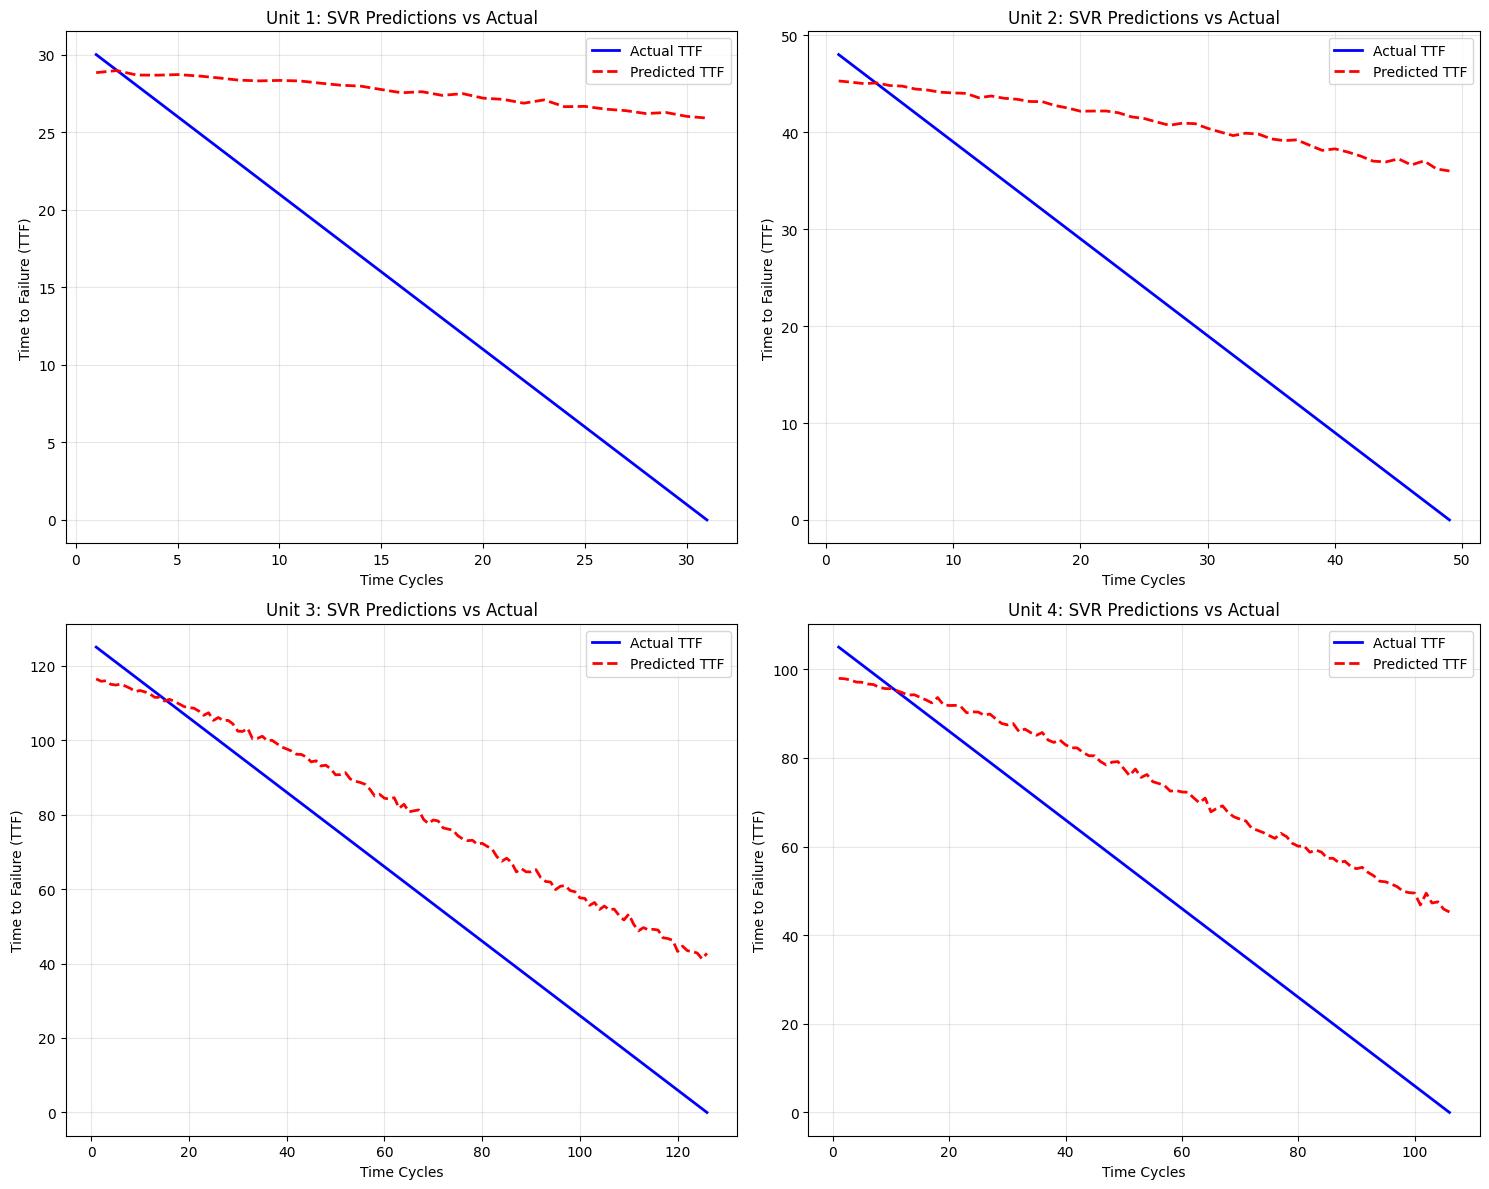

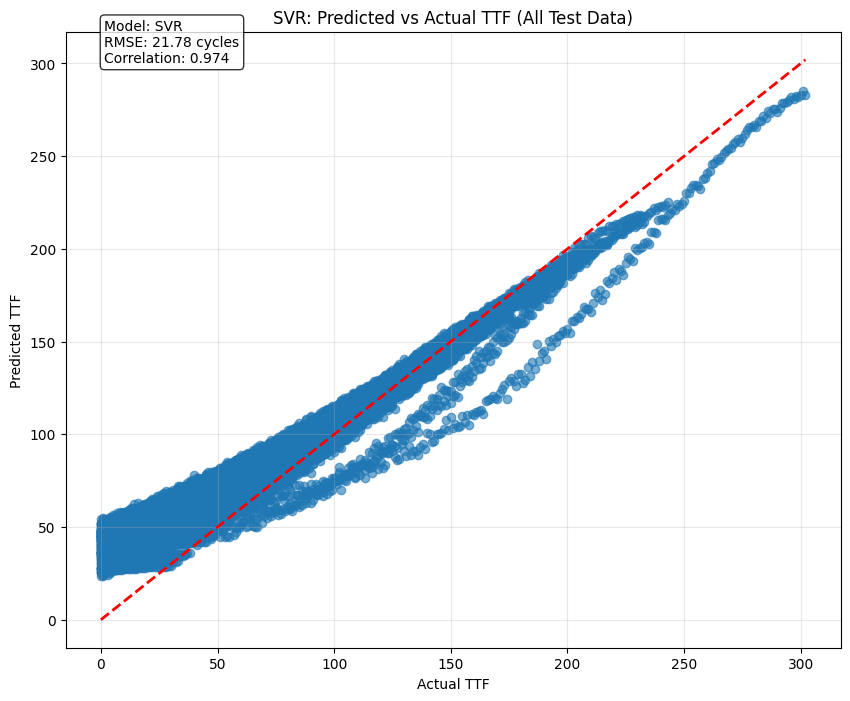

In [103]:
# Visualize predictions for the best model
best_result = results[best_model_name]
Y_pred_test_ttf = best_result['Y_pred_test_ttf']
Y_test_ttf = best_result['Y_test_ttf']

# Plot predictions vs actual for best model
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

# Select first 4 units for time series visualization
units_to_plot = sorted(scaled_test_df['unit_nr'].unique())[:4]
test_max_cycles = scaled_test_df.groupby('unit_nr')['max_cycles'].first()

for i, unit_nr in enumerate(units_to_plot):
    unit_mask = scaled_test_df['unit_nr'] == unit_nr
    max_cycles = test_max_cycles[unit_nr]
    
    # Get time cycles for x-axis
    time_cycles = scaled_test_df[unit_mask]['time_cycles'].values
    
    # Get actual and predicted TTF for this unit
    unit_actual_fttf = Y_test[unit_mask]
    unit_pred_fttf = best_result['Y_pred_test'][unit_mask]
    
    # Convert to TTF scale
    actual_ttf = unit_actual_fttf * max_cycles
    pred_ttf = unit_pred_fttf * max_cycles
    
    # Plot
    axes[i].plot(time_cycles, actual_ttf, 'b-', label='Actual TTF', linewidth=2)
    axes[i].plot(time_cycles, pred_ttf, 'r--', label='Predicted TTF', linewidth=2)
    axes[i].set_title(f'Unit {unit_nr}: {best_model_name} Predictions vs Actual')
    axes[i].set_xlabel('Time Cycles')
    axes[i].set_ylabel('Time to Failure (TTF)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Scatter plot of predicted vs actual TTF for best model
plt.figure(figsize=(10, 8))
plt.scatter(Y_test_ttf, Y_pred_test_ttf, alpha=0.6)
plt.plot([Y_test_ttf.min(), Y_test_ttf.max()], [Y_test_ttf.min(), Y_test_ttf.max()], 'r--', lw=2)
plt.xlabel('Actual TTF')
plt.ylabel('Predicted TTF')
plt.title(f'{best_model_name}: Predicted vs Actual TTF (All Test Data)')
plt.grid(True, alpha=0.3)

# Add metrics
correlation = np.corrcoef(Y_test_ttf, Y_pred_test_ttf)[0, 1]
plt.text(0.05, 0.95, f'Model: {best_model_name}\nRMSE: {best_result["test_rmse_ttf"]:.2f} cycles\nCorrelation: {correlation:.3f}', 
         transform=plt.gca().transAxes, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.show()

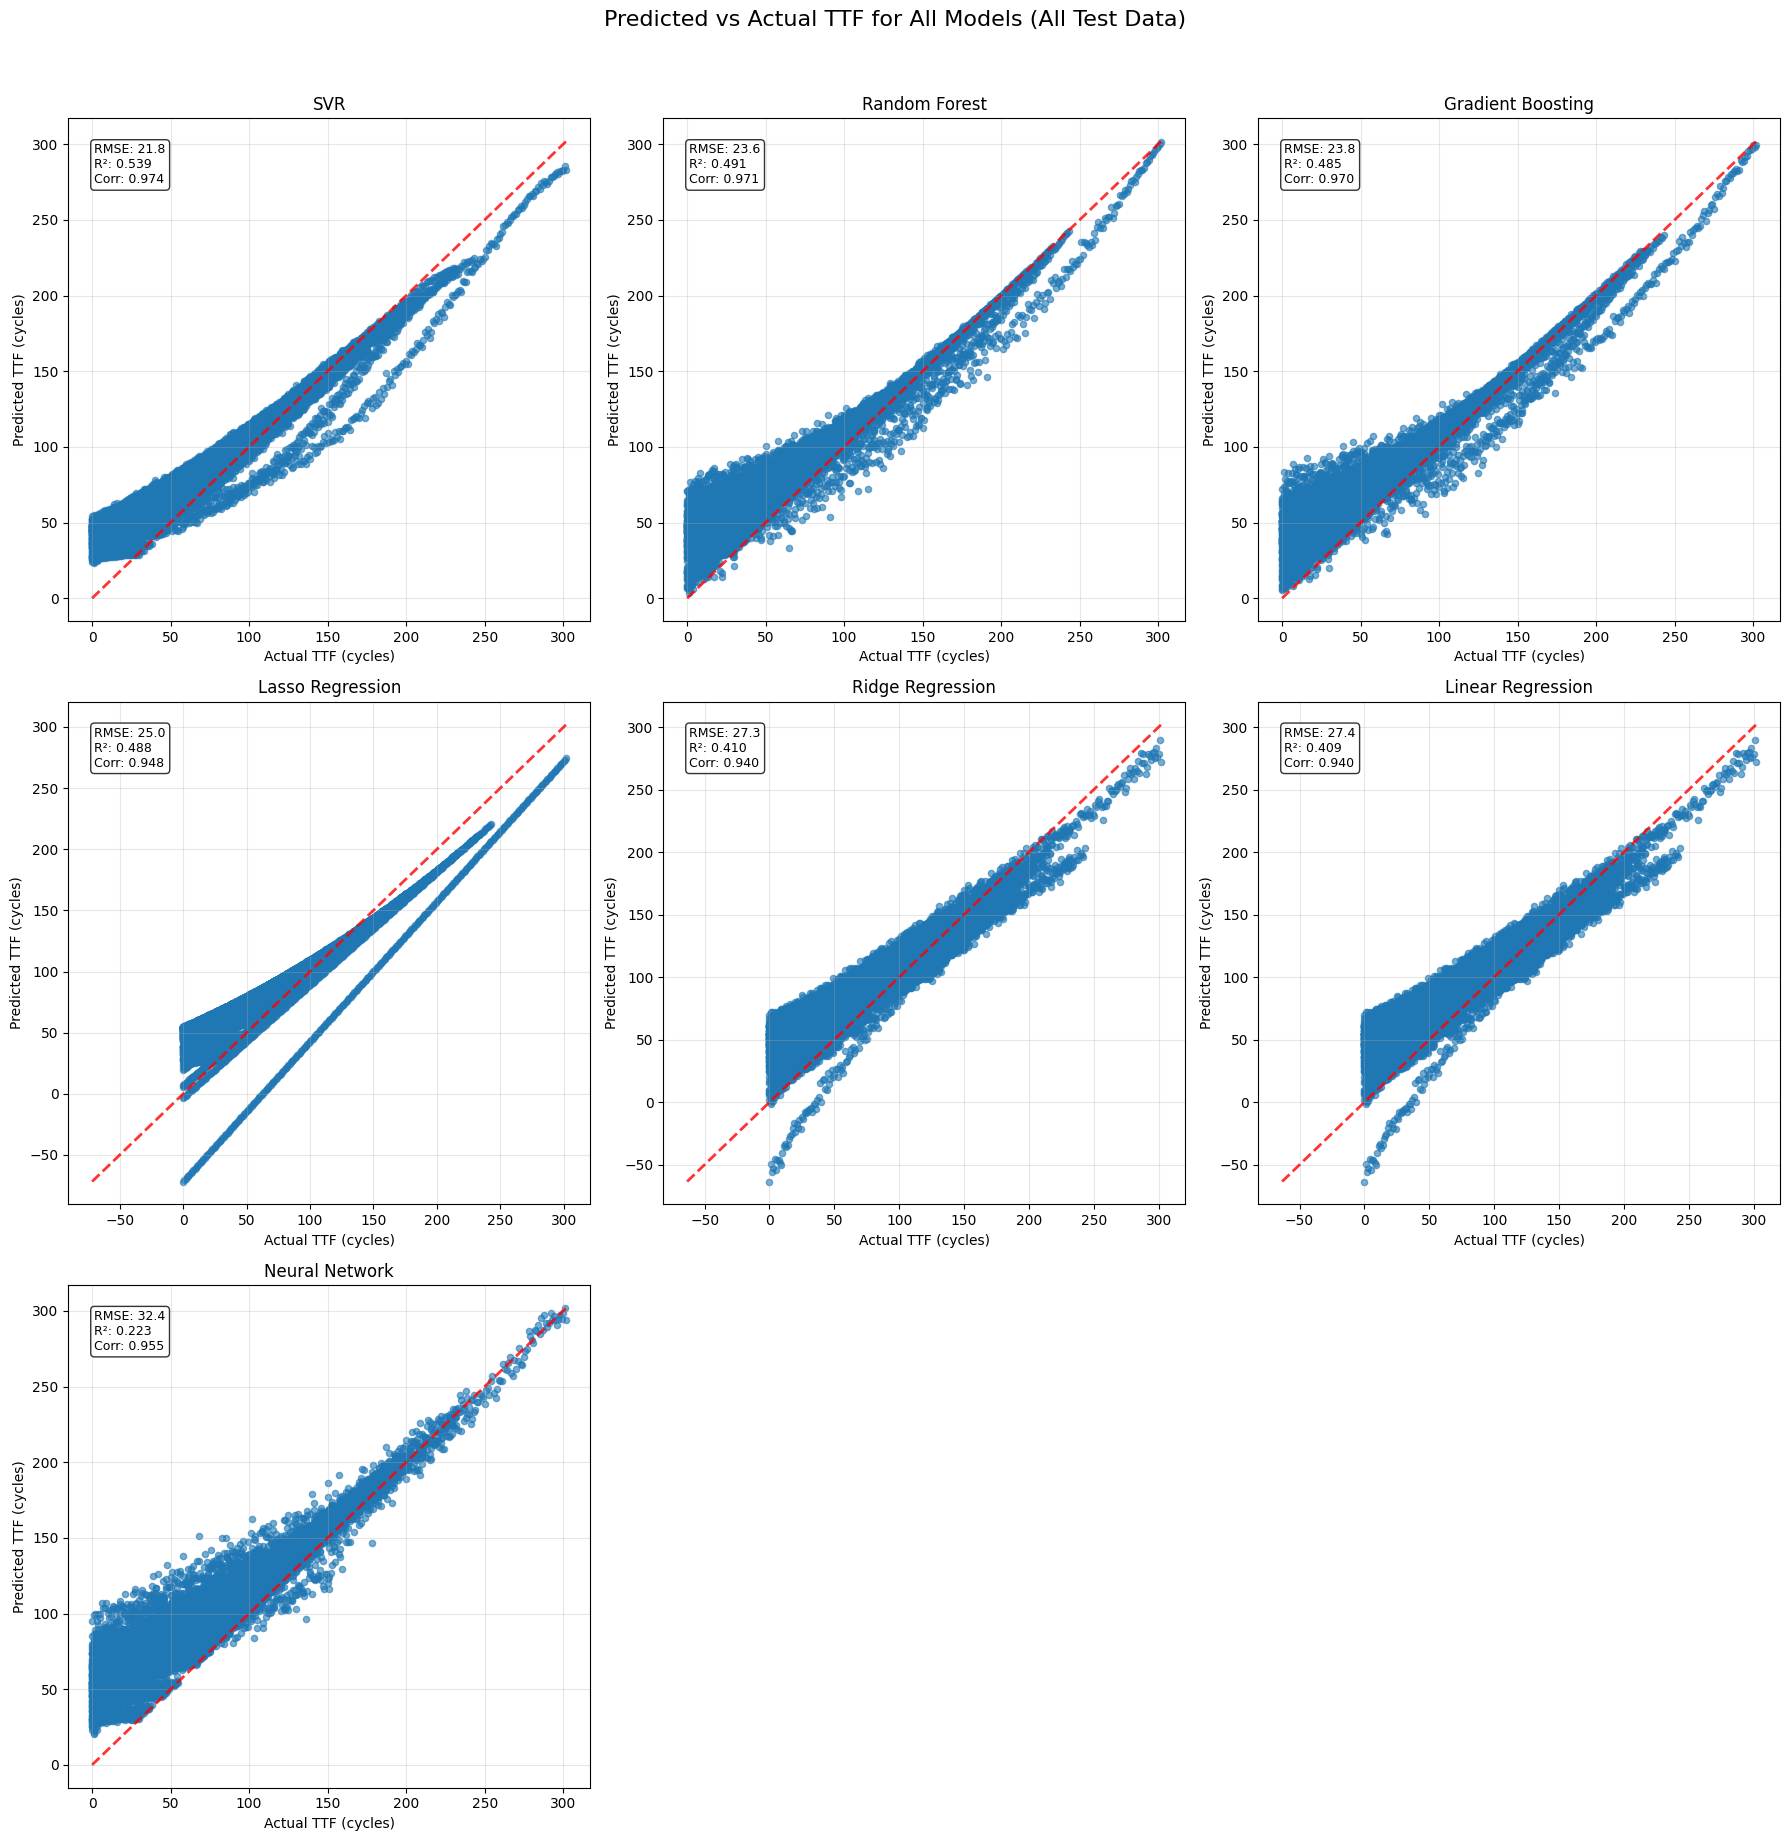

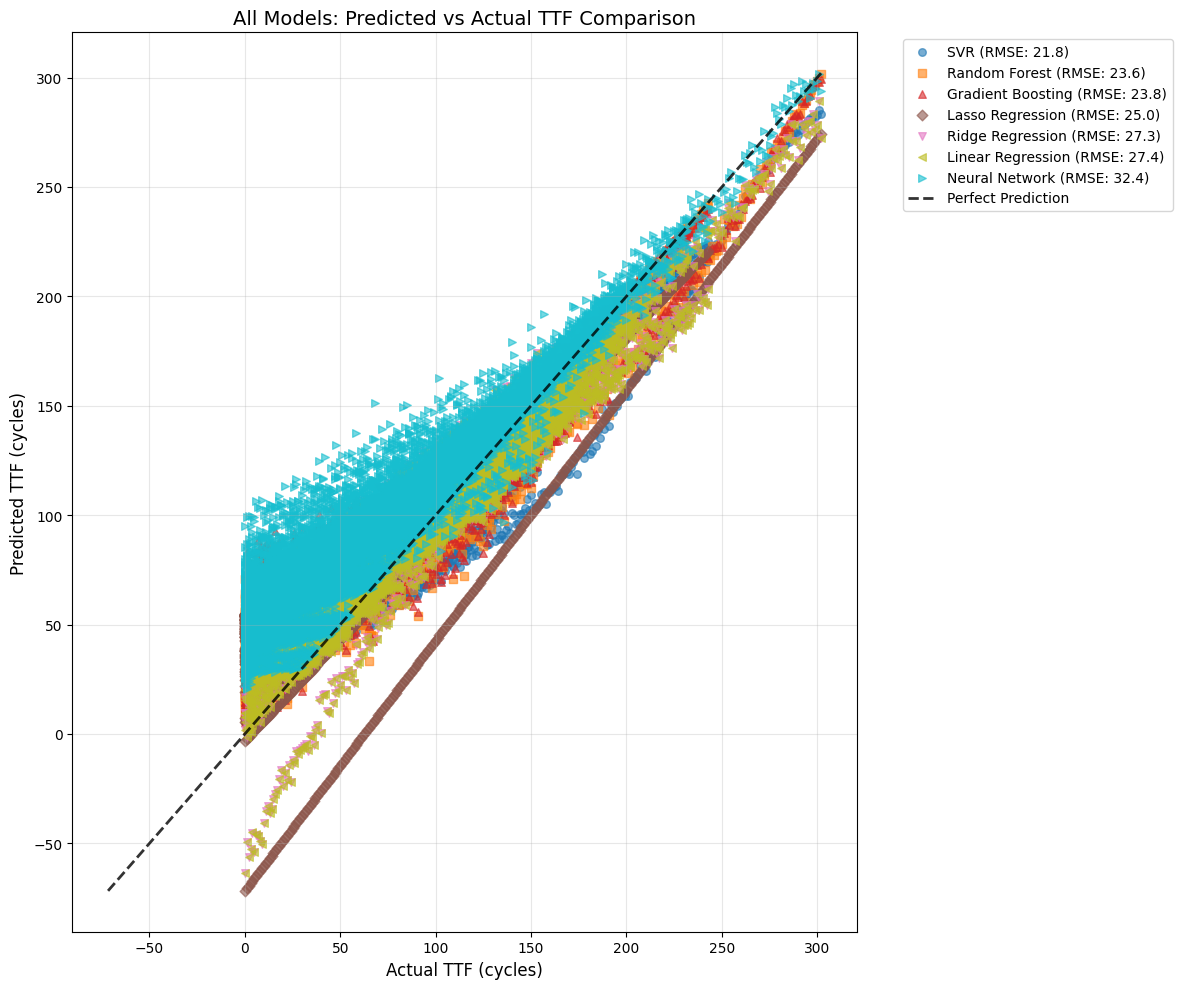

In [104]:
# Create scatter plots for all models showing predicted vs actual TTF
n_models = len(results)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))

# If only one row, make sure axes is always a 2D array
if n_rows == 1:
    axes = axes.reshape(1, -1)
elif n_models == 1:
    axes = axes.reshape(-1, 1)

# Flatten axes for easier indexing
axes_flat = axes.flatten()

# Sort models by performance for consistent ordering
sorted_results = sorted(results.items(), key=lambda x: x[1]['test_rmse_ttf'])

for i, (model_name, result) in enumerate(sorted_results):
    ax = axes_flat[i]
    
    Y_test_ttf = result['Y_test_ttf']
    Y_pred_ttf = result['Y_pred_test_ttf']
    
    # Create scatter plot
    ax.scatter(Y_test_ttf, Y_pred_ttf, alpha=0.6, s=20)
    
    # Add perfect prediction line
    min_val = min(Y_test_ttf.min(), Y_pred_ttf.min())
    max_val = max(Y_test_ttf.max(), Y_pred_ttf.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, alpha=0.8)
    
    # Labels and title
    ax.set_xlabel('Actual TTF (cycles)')
    ax.set_ylabel('Predicted TTF (cycles)')
    ax.set_title(f'{model_name}')
    ax.grid(True, alpha=0.3)
    
    # Add metrics as text
    rmse = result['test_rmse_ttf']
    r2 = result['test_r2_fttf']
    correlation = np.corrcoef(Y_test_ttf, Y_pred_ttf)[0, 1]
    
    metrics_text = f'RMSE: {rmse:.1f}\nR²: {r2:.3f}\nCorr: {correlation:.3f}'
    ax.text(0.05, 0.95, metrics_text, transform=ax.transAxes, 
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
            verticalalignment='top', fontsize=9)

# Hide empty subplots
for i in range(len(sorted_results), len(axes_flat)):
    axes_flat[i].set_visible(False)

plt.suptitle('Predicted vs Actual TTF for All Models (All Test Data)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Create a summary plot showing all models on one graph with different colors
plt.figure(figsize=(12, 10))

colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', 'h', '*']

for i, (model_name, result) in enumerate(sorted_results):
    Y_test_ttf = result['Y_test_ttf']
    Y_pred_ttf = result['Y_pred_test_ttf']
    
    plt.scatter(Y_test_ttf, Y_pred_ttf, alpha=0.6, s=30, 
               color=colors[i], marker=markers[i % len(markers)], 
               label=f'{model_name} (RMSE: {result["test_rmse_ttf"]:.1f})')

# Add perfect prediction line
all_actual = np.concatenate([result['Y_test_ttf'] for result in results.values()])
all_predicted = np.concatenate([result['Y_pred_test_ttf'] for result in results.values()])
min_val = min(all_actual.min(), all_predicted.min())
max_val = max(all_actual.max(), all_predicted.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, alpha=0.8, label='Perfect Prediction')

plt.xlabel('Actual TTF (cycles)', fontsize=12)
plt.ylabel('Predicted TTF (cycles)', fontsize=12)
plt.title('All Models: Predicted vs Actual TTF Comparison', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()